# FinSight Agent — Error Analysis Dashboard

Where does each RAG mode fail, and how? This notebook categorizes every response in the three result CSVs into a single error category (or `CORRECT`), then visualizes the failure-mode profile of each mode.

**Error taxonomy:**

| Category | Definition | Why it matters |
|---|---|---|
| `HALLUCINATION` | Answered a question that *should* have been refused (no info in docs) | Most damaging — produces plausible falsehoods with citations |
| `WRONG_REFUSAL` | Refused a question that the docs actually answer | Frustrating UX; over-cautious router |
| `LOW_RELEVANCE` | Answered but heuristic relevance < 0.6 | Generated a weak/off-topic answer |
| `SLOW` *(orthogonal)* | Latency > 30 s | Demo-killer; user gives up |
| `CORRECT` | None of the above | The good case |

Output: `evaluation/error_analysis_chart.png` + `evaluation/error_analysis.md` writeup.

## 1. Setup and load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

EVAL_DIR = Path('.')
MODES = ['naive', 'agentic', 'multi_agent']
MODE_LABELS = {'naive': 'Naive RAG', 'agentic': 'Agentic RAG', 'multi_agent': 'Multi-Agent RAG'}

# Error category palette
ERR_COLORS = {
    'HALLUCINATION':  '#d62728',  # red
    'WRONG_REFUSAL':  '#ff7f0e',  # orange
    'LOW_RELEVANCE':  '#bcbd22',  # olive
    'CORRECT':        '#2ca02c',  # green
}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10})

# Ground truth: which question_ids should the system refuse?
test_q = pd.read_csv(EVAL_DIR / 'test_questions.csv')
test_q['should_refuse'] = test_q['should_refuse'].astype(str).str.lower() == 'true'
SHOULD_REFUSE = dict(zip(test_q['question_id'], test_q['should_refuse']))
print('Should-refuse IDs:', [q for q, sr in SHOULD_REFUSE.items() if sr])

Should-refuse IDs: ['N1', 'N2', 'N3']


In [2]:
frames = []
for m in MODES:
    df = pd.read_csv(EVAL_DIR / f'results_{m}.csv')
    df['expected_refuse'] = df['question_id'].map(SHOULD_REFUSE).fillna(False)
    frames.append(df)

df = pd.concat(frames, ignore_index=True)
print(f'Loaded {len(df)} rows across {df["mode"].nunique()} modes')

Loaded 45 rows across 3 modes


## 2. Categorize every row

Each row gets a primary `error_category` (priority-ordered) plus an orthogonal `is_slow` flag. Latency is treated as a separate axis because a slow but correct answer is still useful — just painful.

In [3]:
SLOW_THRESHOLD_S = 30.0
LOW_RELEVANCE_THRESHOLD = 0.6

def classify(row):
    # Priority order: most severe first.
    if row['expected_refuse'] and row['decision'] != 'REFUSE':
        return 'HALLUCINATION'
    if (not row['expected_refuse']) and row['decision'] == 'REFUSE':
        return 'WRONG_REFUSAL'
    if row['decision'] == 'ANSWER' and row['relevance'] < LOW_RELEVANCE_THRESHOLD:
        return 'LOW_RELEVANCE'
    return 'CORRECT'

df['error_category'] = df.apply(classify, axis=1)
df['is_slow'] = df['execution_time_s'] > SLOW_THRESHOLD_S

# Quick summary
summary = (
    df.groupby(['mode', 'error_category']).size()
      .unstack(fill_value=0)
      .reindex(MODES)
      .reindex(columns=['CORRECT', 'HALLUCINATION', 'WRONG_REFUSAL', 'LOW_RELEVANCE'], fill_value=0)
)
summary['total'] = summary.sum(axis=1)
summary['slow_count'] = df.groupby('mode')['is_slow'].sum().reindex(MODES).astype(int)
summary

error_category,CORRECT,HALLUCINATION,WRONG_REFUSAL,LOW_RELEVANCE,total,slow_count
mode,,,,,,
naive,11,3,0,1,15,0
agentic,7,0,7,1,15,0
multi_agent,10,1,3,1,15,2


In [4]:
# Same view as percentages
pct = summary.drop(columns=['total', 'slow_count']).div(summary['total'], axis=0) * 100
pct.round(1)

error_category,CORRECT,HALLUCINATION,WRONG_REFUSAL,LOW_RELEVANCE
mode,,,,
naive,73.3,20.0,0.0,6.7
agentic,46.7,0.0,46.7,6.7
multi_agent,66.7,6.7,20.0,6.7


## 3. Visualization — error-mode dashboard

Three panels:

1. **Stacked error breakdown per mode** — proportion of each error type
2. **Absolute error counts per mode** — easier to compare raw failure counts
3. **Latency distribution per mode** — boxplot with the 30 s slowness threshold marked

C:\Users\ANUSHREE ASHOK\AppData\Local\Temp\ipykernel_14280\2897887273.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_by_mode, labels=mode_labels, patch_artist=True, widths=0.55)


Saved: C:\Users\ANUSHREE ASHOK\Desktop\MAIB\Term 5\Advanced Topics in Generative AI\Final Group Assignment\evaluation\error_analysis_chart.png


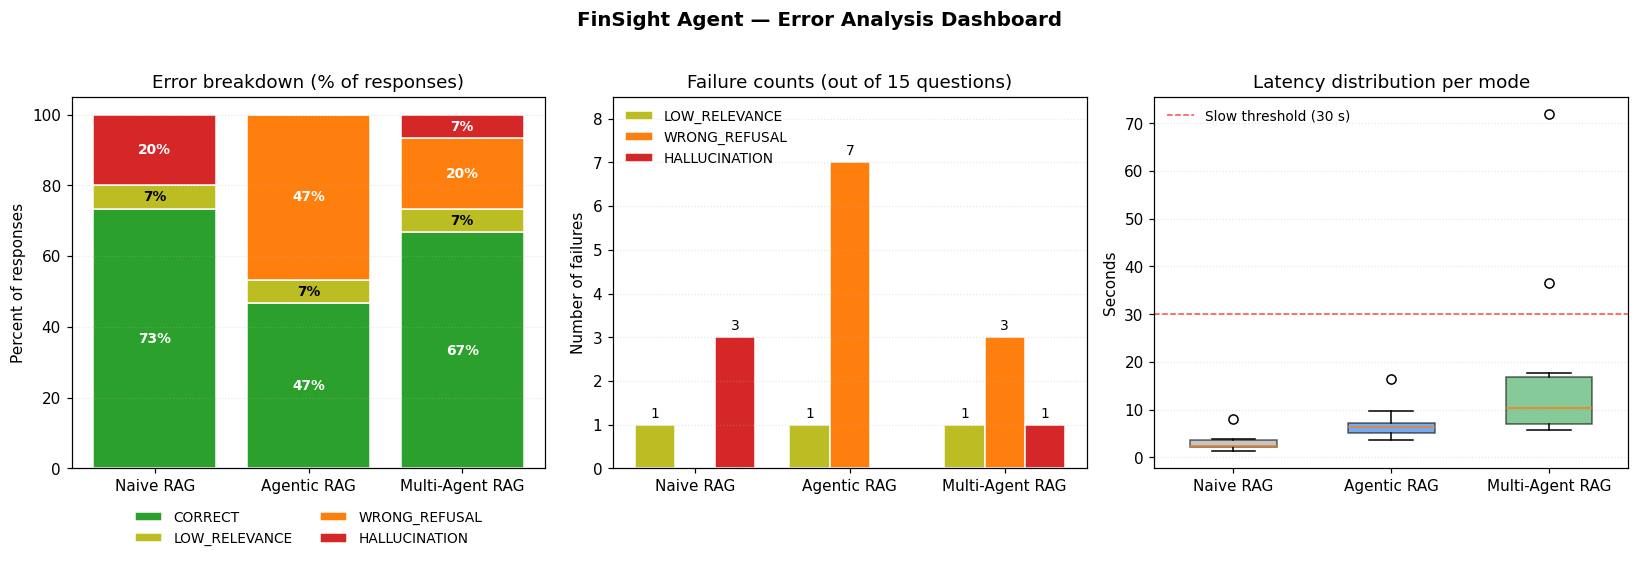

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax1, ax2, ax3 = axes

categories = ['CORRECT', 'LOW_RELEVANCE', 'WRONG_REFUSAL', 'HALLUCINATION']
mode_labels = [MODE_LABELS[m] for m in MODES]

# --- Panel 1: stacked percentage ---
bottoms = np.zeros(len(MODES))
for cat in categories:
    vals = pct[cat].reindex(MODES).values
    ax1.bar(mode_labels, vals, bottom=bottoms, color=ERR_COLORS[cat], edgecolor='white', label=cat)
    # annotate non-zero slices
    for i, v in enumerate(vals):
        if v > 4:
            ax1.text(i, bottoms[i] + v/2, f'{v:.0f}%', ha='center', va='center', fontsize=9,
                     color='white' if cat != 'LOW_RELEVANCE' else 'black', fontweight='bold')
    bottoms += vals
ax1.set_title('Error breakdown (% of responses)')
ax1.set_ylabel('Percent of responses')
ax1.set_ylim(0, 105)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False, fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.3)

# --- Panel 2: absolute counts (grouped bars) ---
err_only = [c for c in categories if c != 'CORRECT']
x = np.arange(len(MODES))
width = 0.26
for i, cat in enumerate(err_only):
    vals = summary[cat].reindex(MODES).values
    bars = ax2.bar(x + (i - 1) * width, vals, width, color=ERR_COLORS[cat], edgecolor='white', label=cat)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(int(v)), ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(mode_labels)
ax2.set_ylabel('Number of failures')
ax2.set_title('Failure counts (out of 15 questions)')
ax2.set_ylim(0, max(summary[err_only].max().max() + 1.5, 3))
ax2.legend(loc='upper left', frameon=False, fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.3)

# --- Panel 3: latency distribution ---
data_by_mode = [df[df['mode'] == m]['execution_time_s'].values for m in MODES]
bp = ax3.boxplot(data_by_mode, labels=mode_labels, patch_artist=True, widths=0.55)
for patch, color in zip(bp['boxes'], ['#9aa0a6', '#1a73e8', '#34a853']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax3.axhline(SLOW_THRESHOLD_S, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Slow threshold ({SLOW_THRESHOLD_S:.0f} s)')
ax3.set_ylabel('Seconds')
ax3.set_title('Latency distribution per mode')
ax3.legend(loc='upper left', frameon=False, fontsize=9)
ax3.grid(axis='y', linestyle=':', alpha=0.3)

fig.suptitle('FinSight Agent — Error Analysis Dashboard', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()

out_path = EVAL_DIR / 'error_analysis_chart.png'
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved: {out_path.resolve()}')
plt.show()

## 4. Annotated failure examples

Pull one concrete example of each error type to make the analysis grounded rather than abstract.

In [6]:
def sample_examples(cat, n=2):
    rows = df[df['error_category'] == cat][['mode', 'question_id', 'question', 'decision', 'answer', 'relevance', 'execution_time_s']]
    return rows.head(n)

for cat in ['HALLUCINATION', 'WRONG_REFUSAL', 'LOW_RELEVANCE']:
    print(f'\n=== {cat} examples ===')
    ex = sample_examples(cat, n=3)
    if ex.empty:
        print('  (none)')
        continue
    for _, r in ex.iterrows():
        print(f"  [{r['mode']:>11}] {r['question_id']} — {r['question'][:80]}")
        print(f"              decision={r['decision']}  relevance={r['relevance']}  latency={r['execution_time_s']}s")
        print(f"              answer: {str(r['answer'])[:160]}")
        print()


=== HALLUCINATION examples ===
  [      naive] N1 — What did Tim Cook say on Twitter yesterday?
              decision=ANSWER  relevance=0.533  latency=1.24s
              answer: The provided context does not contain any information regarding what Tim Cook said on Twitter yesterday. Therefore, I cannot provide an answer to that question.

  [      naive] N2 — What is Apple's stock price right now?
              decision=ANSWER  relevance=0.357  latency=1.65s
              answer: The current stock price of Apple Inc. is $234, as of September 2025 (Source: Apple_10K_2025.pdf, Page: 23).

  [      naive] N3 — What products will Apple launch in 2027?
              decision=ANSWER  relevance=0.947  latency=1.73s
              answer: The provided context does not contain any information about products that Apple will launch in 2027. It only details significant announcements made during fisca


=== WRONG_REFUSAL examples ===
  [    agentic] F4 — What does NVIDIA primarily manufacture?
   

In [7]:
# Slow cases (orthogonal axis)
slow = df[df['is_slow']][['mode', 'question_id', 'question', 'decision', 'execution_time_s', 'error_category']]
print(f'Slow cases (latency > {SLOW_THRESHOLD_S}s): {len(slow)}')
slow

Slow cases (latency > 30.0s): 2


,mode,question_id,question,decision,execution_time_s,error_category
43,multi_agent,N2,What is Apple's stock price right now?,REFUSE,36.53,CORRECT
44,multi_agent,N3,What products will Apple launch in 2027?,ANSWER,71.99,HALLUCINATION


## 5. Per-mode failure profile (one-line summary)

In [8]:
for m in MODES:
    sub = df[df['mode'] == m]
    total = len(sub)
    correct = (sub['error_category'] == 'CORRECT').sum()
    hall = (sub['error_category'] == 'HALLUCINATION').sum()
    wrong = (sub['error_category'] == 'WRONG_REFUSAL').sum()
    lowrel = (sub['error_category'] == 'LOW_RELEVANCE').sum()
    slow_n = sub['is_slow'].sum()
    print(f'{MODE_LABELS[m]:>16}: {correct}/{total} CORRECT — {hall} hallucination(s), {wrong} wrong-refusal(s), {lowrel} low-relevance, {slow_n} slow')

       Naive RAG: 11/15 CORRECT — 3 hallucination(s), 0 wrong-refusal(s), 1 low-relevance, 0 slow
     Agentic RAG: 7/15 CORRECT — 0 hallucination(s), 7 wrong-refusal(s), 1 low-relevance, 0 slow
 Multi-Agent RAG: 10/15 CORRECT — 1 hallucination(s), 3 wrong-refusal(s), 1 low-relevance, 2 slow


---

Findings are written up in [`error_analysis.md`](./error_analysis.md).